Applying PCA on XBP1 ans GATA3


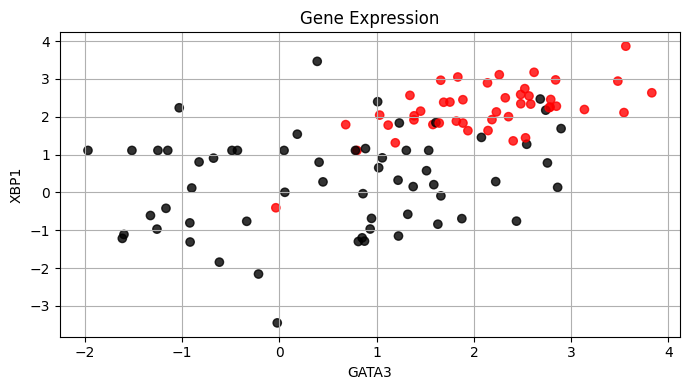

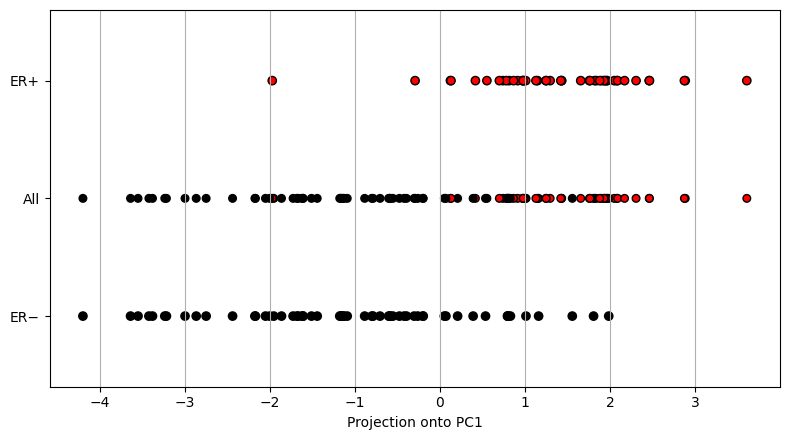

In [16]:
import pandas as pd
import numpy as np
import gzip
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Loading the  data
cl_lab = pd.read_csv("class.tsv", header=None, names=["Class"])["Class"]
columns_df = pd.read_csv("columns.tsv.gz", sep="\t", comment="#")
with gzip.open("filtered.tsv.gz", "rt") as f:
    exp_df = pd.read_csv(f, sep="\t")

# Clean column names
exp_df.columns = exp_df.columns.str.strip()

# Geting the IDs for XBP1 and GATA3
Gene = columns_df.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]["ID"].astype(str).tolist()
sel_exp = exp_df[Gene].copy()
sel_exp.columns = ["XBP1", "GATA3"]

# Scatter plot
plt.figure(figsize=(7, 4))
colors = cl_lab.map({1: "red", 0: "black"})
plt.scatter(sel_exp["XBP1"], sel_exp["GATA3"], c=colors, alpha=0.8)
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Gene Expression")
plt.grid(True)
plt.tight_layout()
plt.show()

# PCA
pca = PCA(n_components=1)
pc1 = pca.fit_transform(sel_exp).flatten()

y_offsets = cl_lab.values
colors = cl_lab.map({1: "red", 0: "black"})

# Ploting begins
plt.figure(figsize=(8, 4.5))
plt.scatter(pc1, y_offsets, c=colors, edgecolor='k', label='ER+/ER−')
plt.scatter(pc1, np.full_like(pc1, 0.5), c=colors, s=30, edgecolor='k', label='All')

# Labels
plt.yticks([1, 0.5, 0], ["ER+", "All", "ER−"])
plt.ylim(-0.3, 1.3)
plt.xlabel("Projection onto PC1")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()
